# Hex Maze Session Inventory 

In [17]:
import numpy as np
import pandas as pd
import datajoint as dj

import spyglass.common as sgc

# Hex maze behavior tables
from spyglass_hexmaze.hex_maze_behavior import (
    HexMazeBlock,
    HexCentroids,
    HexPositionSelection,
    HexPosition,
)
# Hex maze decode tables
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPosition,
    HexMazeDecodedPositionHex,
    HexMazeDecodedHexPath,
)

## Find all sessions in `HexMazeBlock`

In [18]:
# Get all sessions in HexMazeBlock
hex_maze_sessions = sorted(set(HexMazeBlock.fetch('nwb_file_name')))
session_keys = [{'nwb_file_name': s} for s in hex_maze_sessions]

print(f'Found {len(hex_maze_sessions)} hex maze sessions:')
for s in hex_maze_sessions:
    print('   ', s)
    
# Get lab + subject_id for each hex maze session
session_lab = pd.DataFrame((sgc.Session & session_keys).fetch('nwb_file_name', 'subject_id', 'lab_name',
                                                           as_dict=True))

# Get task type
blocks = pd.DataFrame(HexMazeBlock.fetch('nwb_file_name', 'epoch', 'task_type', as_dict=True))
epoch_task = (
    blocks.groupby(['nwb_file_name', 'epoch'])['task_type']
    .agg(lambda x: ', '.join(sorted(set(x))))  # single task type per epoch
    .reset_index()
)

# Attach lab + subject to every epoch
epoch_task = epoch_task.merge(session_lab, on='nwb_file_name', how='left')

# Flag each epoch as barrier vs probability change
epoch_task['is_barrier'] = epoch_task['task_type'].str.contains('barrier', case=False)
epoch_task['is_prob'] = epoch_task['task_type'].str.contains('prob', case=False)

n_sessions = epoch_task['nwb_file_name'].nunique()
n_epochs = len(epoch_task)
print(f'Total hex maze sessions: {n_sessions}')
print(f'Total hex maze epochs:   {n_epochs}')
print(f'Total unique subjects:   {epoch_task["subject_id"].nunique()}')

# Breakdown by lab (sessions, epochs, subjects, task type)
lab_summary = epoch_task.groupby('lab_name').agg(
    n_subjects=('subject_id', 'nunique'),
    n_sessions=('nwb_file_name', 'nunique'),
    n_epochs=('epoch', 'size'),
    n_barrier=('is_barrier', 'sum'),
    n_prob=('is_prob', 'sum'),
)
print('\n By lab: ')
print(lab_summary.to_string())

# Breakdown by subject
subj_summary = epoch_task.groupby('subject_id').agg(
    n_sessions=('nwb_file_name', 'nunique'),
    n_epochs=('epoch', 'size'),
    n_barrier=('is_barrier', 'sum'),
    n_prob=('is_prob', 'sum'),
)
print('\nBy subject')
print(subj_summary.to_string())

# Breakdown by task type
print('\nEpochs by task type')
print(epoch_task['task_type'].value_counts().to_string())

Found 82 hex maze sessions:
    BraveLu20240516_.nwb
    BraveLu20240518_.nwb
    BraveLu20240519_.nwb
    BraveLu20240615_.nwb
    BraveLu20240617_.nwb
    BraveLu20240619_.nwb
    BraveLu20240622_.nwb
    IM-1478_20220719_.nwb
    IM-1478_20220720_.nwb
    IM-1478_20220724_.nwb
    IM-1478_20220725_.nwb
    IM-1478_20220726_.nwb
    IM-1478_20220727_.nwb
    IM-1594_20230725_.nwb
    IM-1594_20230726_.nwb
    IM-1594_20230727_.nwb
    IM-1594_20230728_.nwb
    IM-1830_pacquiao_20250217_.nwb
    IM-1830_pacquiao_20250224_.nwb
    IM-1830_pacquiao_20250226_.nwb
    IM-1830_pacquiao_20250227_.nwb
    IM-1830_pacquiao_20250228_.nwb
    IM-1830_pacquiao_20250407_.nwb
    IM-1830_pacquiao_20250408_.nwb
    IM-1830_pacquiao_20250411_.nwb
    IM-1830_pacquiao_20250414_.nwb
    IM-1830_pacquiao_20250417_.nwb
    IM-1844_elsa_20250408_.nwb
    IM-1844_elsa_20250414_.nwb
    IM-1844_elsa_20250418_.nwb
    IM-1844_elsa_20250423_.nwb
    IM-1844_elsa_20250424_.nwb
    IM-1844_elsa_20250425_.nwb
 

## What data exists for each epoch?

For every hex maze epoch, check whether it has:
- **position**: anything in `PositionOutput`
- **ephys**: anything in `Raw`
- **theta**: anything in `HexMazeThetaV1`
- **sorted**: anything in `SpikeSortingOutput`
- **decoded**: anything in `DecodingOutput`
- **hex decode**: anything in `HexMazeDecodedPosition`

Position, theta, decoding, and hex decode each resolve to a specific epoch. Ephys and sorting are only keyed by session, so for those a session's flag applies to
all of its epochs.

In [ ]:
import re

import spyglass.spikesorting.v1 as sgs
from spyglass.common import Raw
from spyglass.position import PositionOutput
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
# Berke lab IM-* sessions have sort groups in spikesorting v1, Frank lab sessions in v0
from spyglass.spikesorting.v0.spikesorting_recording import SortGroup as SortGroupV0
from spyglass_hexmaze.hex_maze_decoding import HexMazeThetaV1

hex_session_set = set(hex_maze_sessions)


def merge_part_rows(merge_table, attrs):
    """Fetch attrs from every part of a merge table, restricted to hex maze sessions.

    We can't use merge_fetch() here: it drops an ENTIRE part if any one of the requested
    attributes is missing. PositionOutput's parts disagree on how they identify an epoch
    (Trodes keys on interval_list_name, DLC keys on epoch) and PoseV2 has no nwb_file_name
    at all, so merge_fetch would silently skip every DLC-tracked session. Instead we ask
    each part only for the attributes it actually has.
    """
    frames = []
    for part in merge_table.parts(as_objects=True):
        have = [a for a in attrs if a in part.heading.names]
        if 'nwb_file_name' not in have:
            continue  # e.g. PoseV2 -- nothing to tie it back to a session
        frames.append(pd.DataFrame(part.fetch(*have, as_dict=True)))
    df = pd.concat(frames, ignore_index=True)
    return df[df['nwb_file_name'].isin(hex_session_set)]


# Each session's run intervals ("00_r1", "01_r1", ...) and the epoch they belong to
run_intervals = {}
for row in (sgc.TaskEpoch & session_keys).fetch(
    'nwb_file_name', 'epoch', 'interval_list_name', as_dict=True
):
    run_intervals.setdefault(row['nwb_file_name'], {})[row['interval_list_name']] = row['epoch']


def interval_epoch(nwb_file_name, interval_list_name):
    """Get the epoch an interval belongs to.

    Two naming conventions show up across position, decoding, and theta:
      - the run interval itself ("00_r1" for Berke, "07_r4" for Frank), possibly with a
        suffix -- "01_r1_noPreTrialTimes" is that run interval minus pre-trial times,
        so it still belongs to the same epoch
      - a position interval, e.g. "pos 3 valid times"
    """
    name = str(interval_list_name)

    # Run interval, exact or with a suffix
    for interval, epoch in run_intervals[nwb_file_name].items():
        if name.startswith(interval):
            return epoch

    # Position interval
    match = re.match(r'pos (\d+) valid times', name)
    return int(match.group(1)) if match else None


def sort_group_table(nwb_file_name):
    """The SortGroup table (v1 or v0) that holds this session's sort groups."""
    return sgs.SortGroup if nwb_file_name.startswith('IM-') else SortGroupV0


# Session-level: ephys, sort groups, spike sorting
# Raw and SortGroup are keyed by Session, and sorting is always done per session, so each
# of these flags applies to every epoch of that session.
ephys_sessions = set((Raw & session_keys).fetch('nwb_file_name'))

# Having raw ephys is NOT the same as being ready for LFP/theta -- the theta pipeline pulls
# its electrodes from SortGroup, so a session with raw ephys but no sort groups is skipped
# entirely (e.g. BraveLu has 27 epochs of raw ephys but only 7 with sort groups).
sort_group_sessions = {
    nwb for nwb in hex_maze_sessions
    if len(sort_group_table(nwb) & {'nwb_file_name': nwb}) > 0
}

# NOTE: don't use merge_fetch('nwb_file_name') on SpikeSortingOutput! Its v1 part
# (CurationV1) is keyed by sorting_id, so we'd silently miss every v1-sorted session.
# get_restricted_merge_ids walks back to the recording selection for both v0 and v1.
sorted_sessions = {
    nwb for nwb in hex_maze_sessions
    if len(SpikeSortingOutput().get_restricted_merge_ids(
        {'nwb_file_name': nwb}, sources=['v0', 'v1'], restrict_by_artifact=False
    ))
}

# Epoch-level: position, theta, decoding, hex decode
# Position: DLC parts store the epoch directly, the others store "pos {epoch} valid times"
pos = merge_part_rows(PositionOutput(), ('nwb_file_name', 'interval_list_name', 'epoch'))
position_epochs = {
    (nwb, int(epoch) if pd.notna(epoch) else interval_epoch(nwb, interval))
    for nwb, interval, epoch in zip(pos['nwb_file_name'], pos['interval_list_name'], pos['epoch'])
}

# Theta: HexMazeThetaV1 inherits from LFPBandV1, so it records the run interval it ran on
theta = pd.DataFrame(
    (HexMazeThetaV1 & session_keys).fetch(
        'nwb_file_name', 'target_interval_list_name', as_dict=True
    )
)
theta_epochs = {
    (nwb, interval_epoch(nwb, interval))
    for nwb, interval in zip(theta['nwb_file_name'], theta['target_interval_list_name'])
}

# Decoding: the selection tables key on IntervalList.proj(decoding_interval=...), so each
# decode records the interval it ran on -- which gives us the epoch
dec = merge_part_rows(DecodingOutput(), ('nwb_file_name', 'decoding_interval'))
decode_epochs = {
    (nwb, interval_epoch(nwb, interval))
    for nwb, interval in zip(dec['nwb_file_name'], dec['decoding_interval'])
}

# Hex decode: keyed by TaskEpoch, so nwb_file_name + epoch come for free
hex_dec = pd.DataFrame(
    (HexMazeDecodedPosition & session_keys).fetch('nwb_file_name', 'epoch', as_dict=True)
)
hex_decode_epochs = set(zip(hex_dec['nwb_file_name'], hex_dec['epoch']))


def epoch_flag(epoch_set):
    """True for each row of epoch_task whose (session, epoch) is in epoch_set."""
    return [
        (nwb, epoch) in epoch_set
        for nwb, epoch in zip(epoch_task['nwb_file_name'], epoch_task['epoch'])
    ]


epoch_task['has_position'] = epoch_flag(position_epochs)
epoch_task['has_ephys'] = epoch_task['nwb_file_name'].isin(ephys_sessions)
epoch_task['has_sort_group'] = epoch_task['nwb_file_name'].isin(sort_group_sessions)
epoch_task['has_theta'] = epoch_flag(theta_epochs)
epoch_task['has_sorting'] = epoch_task['nwb_file_name'].isin(sorted_sessions)
epoch_task['has_decode'] = epoch_flag(decode_epochs)
epoch_task['has_hex_decode'] = epoch_flag(hex_decode_epochs)

data_cols = ['has_position', 'has_ephys', 'has_sort_group', 'has_theta',
             'has_sorting', 'has_decode', 'has_hex_decode']

# Report by epoch
n_epochs = len(epoch_task)
epoch_counts = epoch_task[data_cols].sum().astype(int)

print(f'Epochs with each data type (out of {n_epochs} epochs):')
for col in data_cols:
    print(f'  {col:16} {epoch_counts[col]:4} / {n_epochs}')

# By lab, with total epochs as the first column
lab_data = epoch_task.groupby('lab_name')[data_cols].sum().astype(int)
lab_data.insert(0, 'n_epochs', epoch_task.groupby('lab_name').size())
print('\nBy lab (epochs):')
print(lab_data.to_string())

# By subject, with total epochs as the first column
subj_data = epoch_task.groupby('subject_id')[data_cols].sum().astype(int)
subj_data.insert(0, 'n_epochs', epoch_task.groupby('subject_id').size())
print('\nBy subject (epochs):')
print(subj_data.to_string())

Epochs with each data type (out of 178 epochs):
  has_position      146 / 178
  has_ephys         154 / 178
  has_sort_group     83 / 178
  has_theta          83 / 178
  has_sorting        53 / 178
  has_decode         47 / 178
  has_hex_decode     39 / 178

By lab (epochs):
             n_epochs  has_position  has_ephys  has_sort_group  has_theta  has_sorting  has_decode  has_hex_decode
lab_name                                                                                                          
Berke Lab          50            30         26              24         24           23          22              19
Loren Frank       128           116        128              59         59           30          25              20

By subject (epochs):
                  n_epochs  has_position  has_ephys  has_sort_group  has_theta  has_sorting  has_decode  has_hex_decode
subject_id                                                                                                             
Br

## Explore decoding parameters per session + epoch

A session+epoch can have several decodes (several `merge_id`s) -- different decoding
parameters, position groups, unit groups, or encoding/decoding intervals. This pulls the
parameters behind every `DecodingOutput` entry for hex maze sessions so you can see what
distinguishes them.

In [20]:
import re
import pandas as pd

import spyglass.common as sgc
from spyglass.decoding.decoding_merge import DecodingOutput
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock

# Hex maze sessions and their run interval -> epoch map (from TaskEpoch)
hex_set = set(HexMazeBlock.fetch('nwb_file_name'))
skeys = [{'nwb_file_name': s} for s in sorted(hex_set)]
runmap = {}
for row in (sgc.TaskEpoch & skeys).fetch('nwb_file_name', 'epoch', 'interval_list_name', as_dict=True):
    runmap.setdefault(row['nwb_file_name'], {})[row['interval_list_name']] = row['epoch']


def decode_epoch(nwb, interval):
    """Epoch for a decode interval -- run interval (full epoch) or an epochN_ name (sub-epoch)."""
    name = str(interval)
    for iv, ep in runmap.get(nwb, {}).items():
        if name.startswith(iv):
            return ep
    m = re.match(r'epoch(\d+)_', name)
    return int(m.group(1)) if m else None


# The parameters that distinguish one decode from another. The decode parts expose these
# through their selection FKs; clusterless has waveform_features_group_name, sorted spikes
# has sorted_spikes_group_name, so we fetch whichever each part actually has.
param_attrs = ['merge_id', 'nwb_file_name', 'decoding_param_name', 'position_group_name',
               'waveform_features_group_name', 'sorted_spikes_group_name',
               'encoding_interval', 'decoding_interval', 'estimate_decoding_params']

frames = []
for part in DecodingOutput().parts(as_objects=True):
    have = [a for a in param_attrs if a in part.heading.names]
    if 'nwb_file_name' not in have:
        continue
    df = pd.DataFrame(part.fetch(*have, as_dict=True))
    if len(df):
        df['source'] = part.table_name.split('__')[-1].strip('`')  # e.g. clusterless_decoding_v1
        frames.append(df)

decode_params = pd.concat(frames, ignore_index=True)
decode_params = decode_params[decode_params['nwb_file_name'].isin(hex_set)].copy()
decode_params['epoch'] = [decode_epoch(n, i)
                          for n, i in zip(decode_params['nwb_file_name'], decode_params['decoding_interval'])]

# Fold the two source-specific group columns into one 'unit_group'
for col in ('waveform_features_group_name', 'sorted_spikes_group_name'):
    if col not in decode_params.columns:
        decode_params[col] = pd.NA
decode_params['unit_group'] = decode_params['waveform_features_group_name'].fillna(
    decode_params['sorted_spikes_group_name'])

decode_params['merge_id'] = decode_params['merge_id'].astype(str)
cols = ['nwb_file_name', 'epoch', 'source', 'decoding_param_name', 'position_group_name',
        'unit_group', 'encoding_interval', 'decoding_interval', 'estimate_decoding_params', 'merge_id']
decode_params = decode_params[cols].sort_values(
    ['nwb_file_name', 'epoch', 'decoding_param_name']).reset_index(drop=True)

print(f'{len(decode_params)} decode entries across '
      f'{decode_params.groupby(["nwb_file_name", "epoch"]).ngroups} session+epochs\n')

# Which decoding_param_name values are in use, and how often
print('Decodes per decoding_param_name:')
print(decode_params['decoding_param_name'].value_counts().to_string())

# Session+epochs that have more than one decode -- and what differs
per_epoch = decode_params.groupby(['nwb_file_name', 'epoch']).agg(
    n_decodes=('merge_id', 'size'),
    param_names=('decoding_param_name', lambda x: ', '.join(sorted(set(x)))),
    unit_groups=('unit_group', lambda x: ', '.join(sorted(set(x.dropna().astype(str))))),
    decode_intervals=('decoding_interval', lambda x: ', '.join(sorted(set(x)))),
).reset_index()
multi = per_epoch[per_epoch['n_decodes'] > 1]
print(f'\n{len(multi)} session+epoch(s) have more than one decode:')
display(multi)

# Full per-decode detail
display(decode_params)

121 decode entries across 48 session+epochs

Decodes per decoding_param_name:
decoding_param_name
contfrag_sorted                                    88
contfrag_sorted_50chunks_100blocks                 30
contfrag_clusterless_50chunks_100block_2halfbin     2
contfrag_sorted_50chunks_100blocks_2halfbin         1

19 session+epoch(s) have more than one decode:


,nwb_file_name,epoch,n_decodes,param_names,unit_groups,decode_intervals
0,IM-1478_20220719_.nwb,0,2,contfrag_sorted_50chunks_100blocks,sorted_spikes_group,"00_r1, epoch0_block1"
2,IM-1478_20220724_.nwb,0,2,contfrag_sorted_50chunks_100blocks,sorted_spikes_group,"00_r1, epoch0_block1"
3,IM-1478_20220725_.nwb,0,3,contfrag_clusterless_50chunks_100block_2halfbi...,1000uV_artifact_70uV_detection_custom_channels...,"00_r1, epoch0_block1"
4,IM-1478_20220726_.nwb,0,2,contfrag_sorted_50chunks_100blocks,sorted_spikes_group,"00_r1, epoch0_block1"
6,IM-1594_20230725_.nwb,0,3,contfrag_clusterless_50chunks_100block_2halfbi...,1000uV_artifact_65uV_detection_custom_channels...,"00_r1, epoch0_block1"
14,IM-1871_20250804_.nwb,0,2,contfrag_sorted_50chunks_100blocks,"sorted_spikes_group, sorted_spikes_group_defau...",00_r1
18,IM-1947_20260401_.nwb,0,2,contfrag_sorted_50chunks_100blocks,sorted_spikes_group,"00_r1, epoch0_block1"
24,Lily20251217_.nwb,3,5,contfrag_sorted,LilyV0_curated,"03_r2_noPreTrialTimes, epoch3_barrierShiftInte..."
32,Toby20250316_.nwb,1,5,"contfrag_sorted, contfrag_sorted_50chunks_100b...","TobyV0_curated, sorted_spikes_group","01_r1_noPreTrialTimes, epoch1_block1, epoch1_b..."
33,Toby20250316_.nwb,3,10,contfrag_sorted,TobyV0_curated,"03_r2_noPreTrialTimes, epoch3_barrierShiftInte..."


,nwb_file_name,epoch,source,decoding_param_name,position_group_name,unit_group,encoding_interval,decoding_interval,estimate_decoding_params,merge_id
0,IM-1478_20220719_.nwb,0,sorted_spikes_decoding_v1,contfrag_sorted_50chunks_100blocks,sorted_spikes_pos_group,sorted_spikes_group,00_r1,00_r1,1,14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf
1,IM-1478_20220719_.nwb,0,sorted_spikes_decoding_v1,contfrag_sorted_50chunks_100blocks,sorted_spikes_pos_group,sorted_spikes_group,00_r1,epoch0_block1,1,cd31d3b2-5b10-c450-3384-8244f40629fa
2,IM-1478_20220720_.nwb,0,sorted_spikes_decoding_v1,contfrag_sorted_50chunks_100blocks,sorted_spikes_pos_group,sorted_spikes_group,00_r1,00_r1,1,5b8a121f-5e12-c8a3-95dc-e48d3bb97295
3,IM-1478_20220724_.nwb,0,sorted_spikes_decoding_v1,contfrag_sorted_50chunks_100blocks,sorted_spikes_pos_group,sorted_spikes_group,00_r1,00_r1,1,3bc86da6-6dfb-cdb2-4447-5a05ece3718b
4,IM-1478_20220724_.nwb,0,sorted_spikes_decoding_v1,contfrag_sorted_50chunks_100blocks,sorted_spikes_pos_group,sorted_spikes_group,00_r1,epoch0_block1,1,6bd30d68-9e26-48cf-f1aa-003ddaf47a1f
...,...,...,...,...,...,...,...,...,...,...
116,Toby20250327_.nwb,7,sorted_spikes_decoding_v1,contfrag_sorted,test_epoch7,TobyV0_curated,epoch7_block1,epoch7_nonLocal_ALL,0,1e79fec7-4db5-d351-e83a-f9ac637aebed
117,Toby20250327_.nwb,7,sorted_spikes_decoding_v1,contfrag_sorted,test_epoch7,TobyV0_curated,epoch7_block2,epoch7_nonLocal_ALL,0,8bcf939b-bd73-2792-2d06-dbbf1a4234df
118,Toby20250327_.nwb,7,sorted_spikes_decoding_v1,contfrag_sorted,test_epoch7,TobyV0_curated,epoch7_block3,epoch7_nonLocal_ALL,0,e25a87f7-2bbd-f2f6-92b7-c47abbb7abd6
119,Toby20250327_.nwb,7,sorted_spikes_decoding_v1,contfrag_sorted,test_epoch7,TobyV0_curated,epoch7_block4,epoch7_nonLocal_ALL,0,f1802561-2a24-8fbb-a932-0bfa8604bec6


## Full epoch inventory

One row per hex maze epoch: lab, subject, session, epoch, and what data exists for it.

In [21]:
# One row per epoch: lab, subject, session, epoch, then the has_* data columns
epoch_inventory = epoch_task[
    ['lab_name', 'subject_id', 'nwb_file_name', 'epoch'] + data_cols
].copy()

epoch_inventory = epoch_inventory.rename(
    columns={'lab_name': 'lab', 'subject_id': 'subject', 'nwb_file_name': 'session'}
)

epoch_inventory = epoch_inventory.sort_values(
    ['lab', 'subject', 'session', 'epoch']
).reset_index(drop=True)

print(f'{len(epoch_inventory)} epochs')
display(epoch_inventory)

178 epochs


,lab,subject,session,epoch,has_position,has_ephys,has_sort_group,has_theta,has_sorting,has_decode,has_hex_decode
0,Berke Lab,IM-1478,IM-1478_20220719_.nwb,0,True,True,True,True,True,True,True
1,Berke Lab,IM-1478,IM-1478_20220720_.nwb,0,True,True,True,True,True,True,True
2,Berke Lab,IM-1478,IM-1478_20220724_.nwb,0,True,True,True,True,True,True,True
3,Berke Lab,IM-1478,IM-1478_20220725_.nwb,0,True,True,True,True,True,True,True
4,Berke Lab,IM-1478,IM-1478_20220726_.nwb,0,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
173,Loren Frank,Toby,Toby20250329_.nwb,1,True,True,False,False,False,False,False
174,Loren Frank,Toby,Toby20250329_.nwb,3,True,True,False,False,False,False,False
175,Loren Frank,Toby,Toby20250329_.nwb,5,True,True,False,False,False,False,False
176,Loren Frank,Toby,Toby20250330_.nwb,1,True,True,False,False,False,False,False


## Epoch to-dos

For each epoch, what's the next processing step (or `done`). The pipeline order is:

`position -> ephys -> sort groups -> sorting -> decode -> hex decode`

also ` ... -> sort groups -> theta`

- **no ephys** (behavior / photometry only): done once position is processed
- **ephys**: next is to create sort groups
- **sort groups**: next is to run theta and sorting (these can go in parallel)
- **sorting** + next is to run decode
- **decoded**: next is to populate hex decode tables

In [22]:
def next_step(row):
    """The next processing step for a single epoch, or 'done'."""
    # If no ephys, the only possible task is run position
    if not row.has_ephys:
        return 'done' if row.has_position else 'run position'

    # Steps for sessions with ephys
    steps = []
    if not row.has_position:
        steps.append('position')

    if not row.has_sort_group:
        # Nothing downstream can run until sort groups exist
        steps.append('sorting (create sort groups)')
    else:
        # once we have sortgroups we can do theta and sorting in parallel
        if not row.has_theta:
            steps.append('theta')
        if not row.has_sorting:
            steps.append('sorting')
        # need sorting for decode and hex decode
        else:
            if not row.has_decode:
                steps.append('decode')
            elif not row.has_hex_decode:
                steps.append('hex decode')

    return 'run ' + '; '.join(steps) if steps else 'done'


epoch_todos = epoch_task.copy()
epoch_todos['next_step'] = epoch_todos.apply(next_step, axis=1)

epoch_todos = (
    epoch_todos
    .rename(columns={'lab_name': 'lab', 'subject_id': 'subject', 'nwb_file_name': 'session'})
    [['lab', 'subject', 'session', 'epoch', 'next_step']]
    .sort_values(['lab', 'subject', 'session', 'epoch'])
    .reset_index(drop=True)
)

print('Epochs by next step:')
print(epoch_todos['next_step'].value_counts().to_string())
print(f"\n{(epoch_todos['next_step'] == 'done').sum()} / {len(epoch_todos)} epochs done\n")
display(epoch_todos)

Epochs by next step:
next_step
run sorting (create sort groups)              64
done                                          43
run sorting                                   25
run position                                  20
run hex decode                                 8
run position; sorting (create sort groups)     7
run decode                                     6
run position; sorting                          5

43 / 178 epochs done



,lab,subject,session,epoch,next_step
0,Berke Lab,IM-1478,IM-1478_20220719_.nwb,0,done
1,Berke Lab,IM-1478,IM-1478_20220720_.nwb,0,done
2,Berke Lab,IM-1478,IM-1478_20220724_.nwb,0,done
3,Berke Lab,IM-1478,IM-1478_20220725_.nwb,0,done
4,Berke Lab,IM-1478,IM-1478_20220726_.nwb,0,done
...,...,...,...,...,...
173,Loren Frank,Toby,Toby20250329_.nwb,1,run sorting (create sort groups)
174,Loren Frank,Toby,Toby20250329_.nwb,3,run sorting (create sort groups)
175,Loren Frank,Toby,Toby20250329_.nwb,5,run sorting (create sort groups)
176,Loren Frank,Toby,Toby20250330_.nwb,1,run sorting (create sort groups)


## Pipeline progress heatmap

One row per epoch, one column per pipeline stage (in order). A filled cell means that
stage is populated. Epochs are grouped by subject, so each animal is a contiguous block
and you can see how far its sessions have gotten. Because theta runs in parallel with the
sorting -> decode branch, a row can have gaps -- this is a status matrix, not a strict funnel.

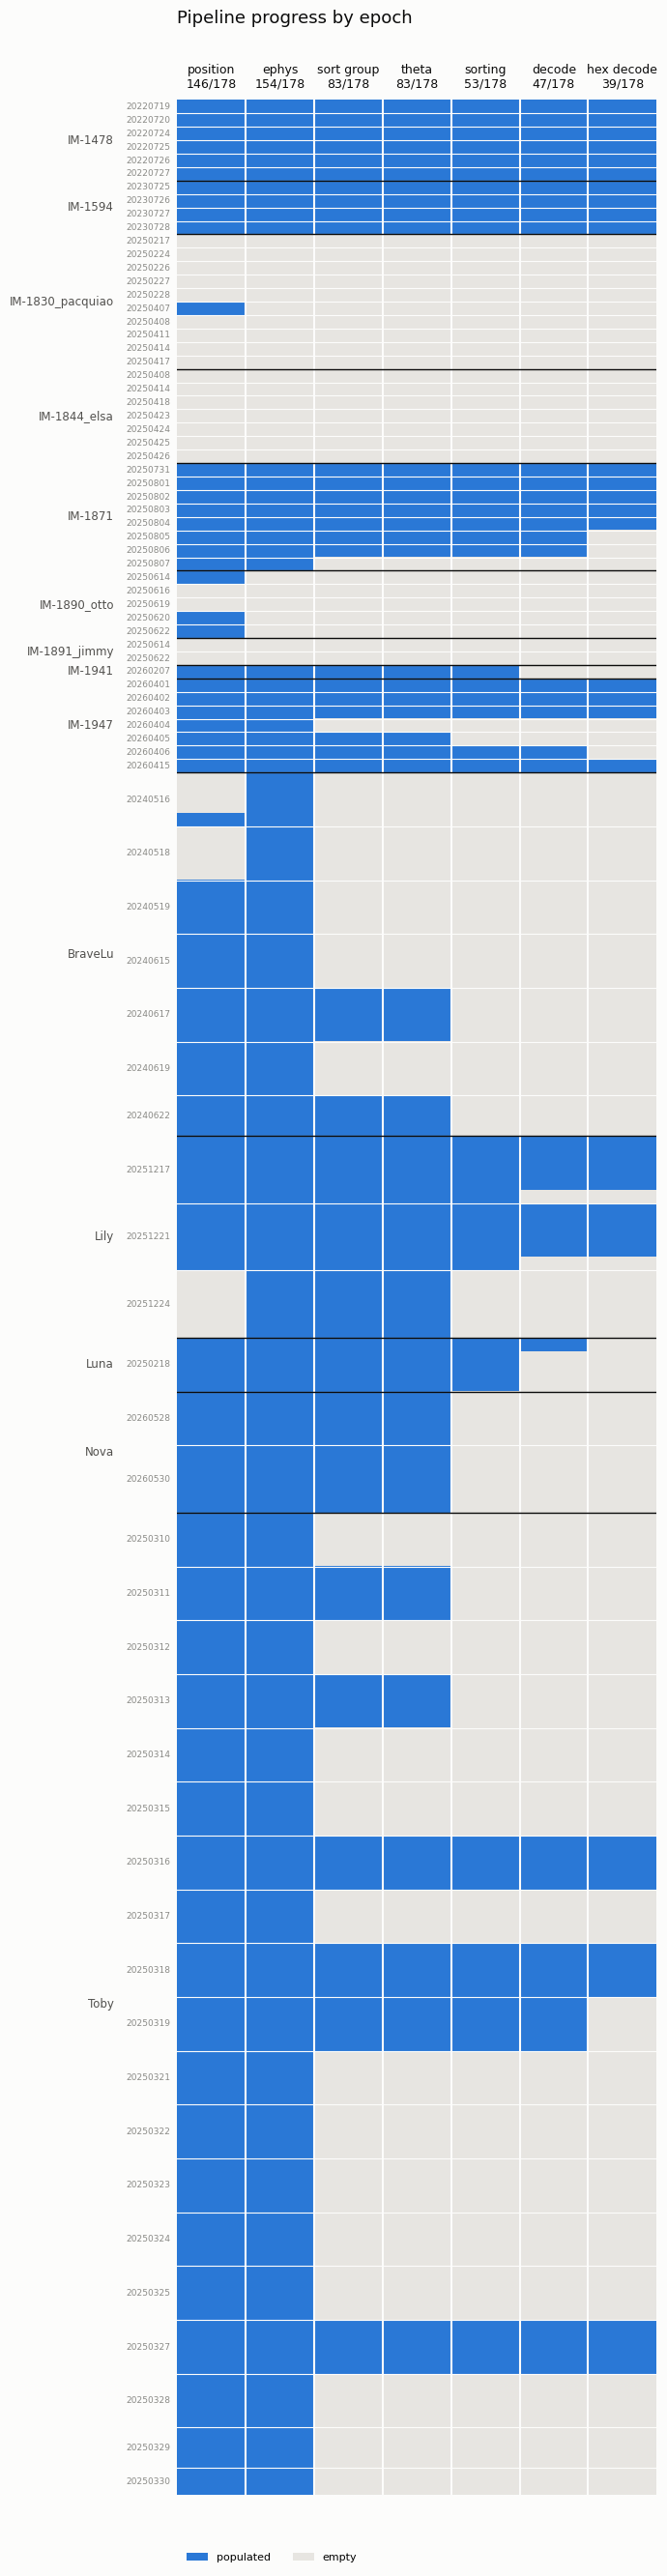

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Stages in pipeline order, and friendly labels
stage_cols = ['has_position', 'has_ephys', 'has_sort_group', 'has_theta',
              'has_sorting', 'has_decode', 'has_hex_decode']
stage_labels = ['position', 'ephys', 'sort group', 'theta', 'sorting', 'decode', 'hex decode']

# Group epochs by subject (then session, epoch) so each animal is a contiguous block
ordered = epoch_task.sort_values(
    ['lab_name', 'subject_id', 'nwb_file_name', 'epoch']
).reset_index(drop=True)
M = ordered[stage_cols].astype(int).to_numpy()
n = len(ordered)


def short_session(nwb_file_name, subject_id):
    '''Trim a session name to just its date, e.g. Toby20250316_.nwb -> 20250316.'''
    s = nwb_file_name.replace('_.nwb', '').replace('.nwb', '')
    if s.startswith(subject_id):
        s = s[len(subject_id):].lstrip('_')
    return s or nwb_file_name


# Colors: one validated blue for 'populated' against a recessive neutral for 'empty'.
# A two-state status encoding -- blue vs light gray is inherently colorblind-safe.
SURFACE = '#fcfcfb'   # chart surface
EMPTY   = '#e7e5e1'   # recessive neutral
FILLED  = '#2a78d6'   # sequential blue 450
INK     = '#0b0b0b'   # primary text
INK2    = '#52514e'   # secondary text (subject labels)
INK3    = '#8a8a86'   # muted text (session labels)
cmap = ListedColormap([EMPTY, FILLED])

# Row height chosen so consecutive single-epoch sessions don't crowd their labels
ROW_H = 0.16
fig, ax = plt.subplots(figsize=(8, max(6, n * ROW_H)))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.imshow(M, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=1)

# 2px surface gaps between stage columns
for i in range(1, len(stage_cols)):
    ax.axvline(i - 0.5, color=SURFACE, lw=1.5)

# Stage labels on top, each with its completion count (n populated / total)
ax.set_xticks(range(len(stage_labels)))
ax.set_xticklabels(
    [f'{lab}\n{int(M[:, i].sum())}/{n}' for i, lab in enumerate(stage_labels)],
    fontsize=9, color=INK,
)
ax.xaxis.set_ticks_position('top')
ax.tick_params(top=False, left=False)

# Measure how wide a date label is (in data-x units) so the subject labels can be
# right-justified snug against the dates' left edge -- no matter the font/DPI.
DATE_X = -0.6                       # right edge where date labels are anchored
fig.canvas.draw()
_probe = ax.text(0, 0, '00000000', fontsize=6.5)
_bb = _probe.get_window_extent(renderer=fig.canvas.get_renderer())
_probe.remove()
(_x0, _), (_x1, _) = ax.transData.inverted().transform([(0, 0), (_bb.width, 0)])
date_w = abs(_x1 - _x0)
subj_x = DATE_X - date_w - 0.3      # subject right edge sits just left of the dates

# Inner level: session (date) labels + hairline dividers between sessions
start = 0
for nwb, sz in ordered.groupby('nwb_file_name', sort=False).size().items():
    lo, hi = start, start + sz
    if start > 0:
        ax.axhline(lo - 0.5, color=SURFACE, lw=0.8)          # thin gap between sessions
    subj = ordered.iloc[lo]['subject_id']
    ax.text(DATE_X, (lo + hi - 1) / 2, short_session(nwb, subj),
            ha='right', va='center', fontsize=6.5, color=INK3, clip_on=False)
    start = hi

# Outer level: subject labels + darker dividers between subjects (drawn on top)
start = 0
for subj, sz in ordered.groupby('subject_id', sort=False).size().items():
    lo, hi = start, start + sz
    if start > 0:
        ax.axhline(lo - 0.5, color=INK, lw=1.0)              # divider between animals
    ax.text(subj_x, (lo + hi - 1) / 2, subj,
            ha='right', va='center', fontsize=8.5, color=INK2, clip_on=False)
    start = hi

ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    handles=[Patch(facecolor=FILLED, label='populated'),
             Patch(facecolor=EMPTY, label='empty')],
    loc='upper left', bbox_to_anchor=(0, -0.02), ncol=2, frameon=False, fontsize=8,
)
ax.set_title('Pipeline progress by epoch', fontsize=13, color=INK, loc='left', pad=30)

fig.subplots_adjust(left=0.28, top=0.92, bottom=0.05)
plt.show()